          Model           MAE          RMSE        R2
0        Linear  15954.172745  19940.848786  0.998112
1  DecisionTree  35503.008869  44763.997031  0.990487
2           kNN  50483.709184  62928.876368  0.981200


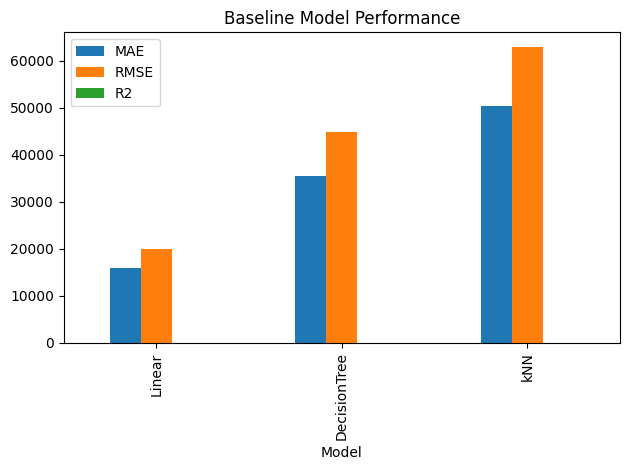

In [4]:
# =========================
# RQ1: Baseline Models
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor

# Load data
df = pd.read_csv("house_price_50k.csv")

# Target detection
target = "SalePrice" if "SalePrice" in df.columns else df.columns[-1]

X = df.drop(columns=[target])
y = df[target]

# Encoding
X = pd.get_dummies(X, drop_first=True)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Models
models = {
    "Linear": LinearRegression(),
    "DecisionTree": DecisionTreeRegressor(),
    "kNN": KNeighborsRegressor()
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    
    results.append([name, mae, rmse, r2])

results = pd.DataFrame(results, columns=["Model", "MAE", "RMSE", "R2"])
print(results)

# Save table
results.to_csv("rq1_table.csv", index=False)

# Plot
results.set_index("Model")[["MAE", "RMSE", "R2"]].plot(kind="bar")
plt.title("Baseline Model Performance")
plt.tight_layout()
plt.savefig("rq1_figure.pdf")
plt.show()

          Model            MAE           RMSE        R2
2       XGBoost   18687.909376   23415.484402  0.997389
0  RandomForest   22847.570073   28573.801728  0.996111
1           SVR  393480.730404  456507.108286  0.007406


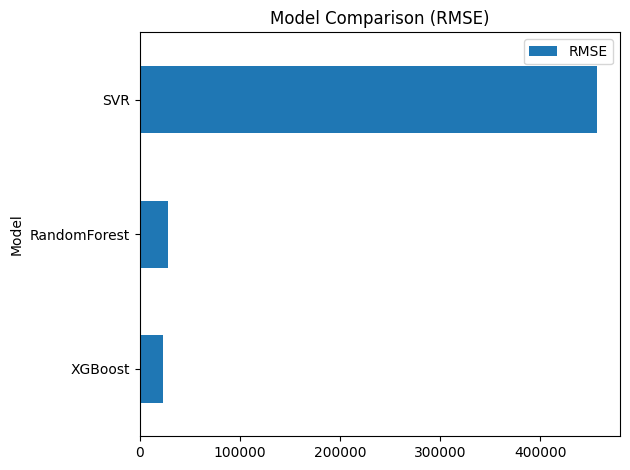

In [1]:
# =========================
# RQ2: Advanced Models
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

# Optional XGBoost safe import
try:
    from xgboost import XGBRegressor
    xgb_available = True
except:
    xgb_available = False

df = pd.read_csv("house_price_50k.csv")
target = "SalePrice" if "SalePrice" in df.columns else df.columns[-1]

X = pd.get_dummies(df.drop(columns=[target]), drop_first=True)
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

models = {
    "RandomForest": RandomForestRegressor(n_estimators=100, random_state=42),
    "SVR": SVR()
}

if xgb_available:
    models["XGBoost"] = XGBRegressor(n_estimators=100, random_state=42)

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    results.append([
        name,
        mean_absolute_error(y_test, pred),
        np.sqrt(mean_squared_error(y_test, pred)),
        r2_score(y_test, pred)
    ])

results = pd.DataFrame(results, columns=["Model", "MAE", "RMSE", "R2"])
results = results.sort_values("RMSE")

print(results)
results.to_csv("rq2_table.csv", index=False)

# Plot
results.plot(x="Model", y="RMSE", kind="barh")
plt.title("Model Comparison (RMSE)")
plt.tight_layout()
plt.savefig("rq2_figure.pdf")
plt.show()

     Stage          RMSE
0      Raw  28585.762834
1  Imputed  28523.641297
2   Scaled  28595.781172


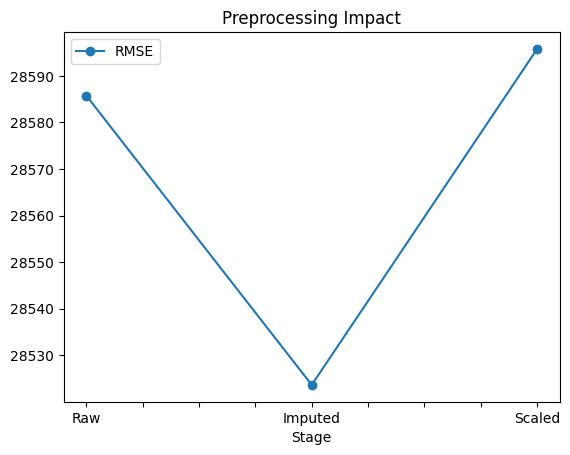

In [9]:
# =========================
# RQ3: Preprocessing Impact
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

df = pd.read_csv("house_price_50k.csv")
target = "SalePrice" if "SalePrice" in df.columns else df.columns[-1]

X = pd.get_dummies(df.drop(columns=[target]), drop_first=True)
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

pipelines = {
    "Raw": Pipeline([("model", RandomForestRegressor())]),
    "Imputed": Pipeline([("imp", SimpleImputer()), ("model", RandomForestRegressor())]),
    "Scaled": Pipeline([("imp", SimpleImputer()), ("scaler", StandardScaler()), ("model", RandomForestRegressor())])
}

results = []

for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    results.append([name, rmse])

results = pd.DataFrame(results, columns=["Stage", "RMSE"])
print(results)

results.to_csv("rq3_table.csv", index=False)

# Plot
results.plot(x="Stage", y="RMSE", marker="o")
plt.title("Preprocessing Impact")
plt.savefig("rq3_figure.pdf")
plt.show()

               Feature  Importance
0                 area    0.983698
4                  age    0.004314
17    location_premium    0.003664
1             bedrooms    0.001915
5             distance    0.001384
16     location_medium    0.001151
18    income_level_low    0.000996
14          crime_rate    0.000828
15  population_density    0.000620
2            bathrooms    0.000408


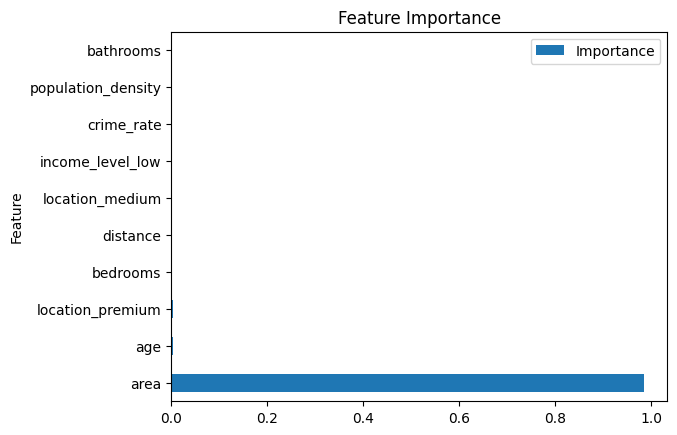

In [5]:
# =========================
# RQ4: Feature Importance
# =========================

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

df = pd.read_csv("house_price_50k.csv")
target = "SalePrice" if "SalePrice" in df.columns else df.columns[-1]

X = pd.get_dummies(df.drop(columns=[target]), drop_first=True)
y = df[target]

model = RandomForestRegressor(n_estimators=100)
model.fit(X, y)

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=False).head(10)

print(importance)

importance.to_csv("rq4_table.csv", index=False)

# Plot
importance.plot(x="Feature", y="Importance", kind="barh")
plt.title("Feature Importance")
plt.savefig("rq4_figure.pdf")
plt.show()

    Model           MAE          RMSE        R2
0  Linear  15953.239681  19977.422638  0.998099
1      RF  22882.286329  28590.071237  0.996107


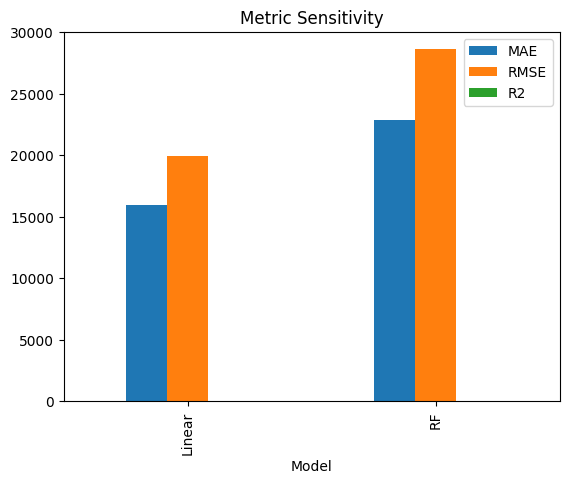

In [6]:
# =========================
# RQ5: Metric Sensitivity
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv("house_price_50k.csv")
target = "SalePrice" if "SalePrice" in df.columns else df.columns[-1]

X = pd.get_dummies(df.drop(columns=[target]), drop_first=True)
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

models = {
    "Linear": LinearRegression(),
    "RF": RandomForestRegressor()
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    results.append([
        name,
        mean_absolute_error(y_test, pred),
        np.sqrt(mean_squared_error(y_test, pred)),
        r2_score(y_test, pred)
    ])

results = pd.DataFrame(results, columns=["Model", "MAE", "RMSE", "R2"])
print(results)

results.to_csv("rq5_table.csv", index=False)

results.set_index("Model").plot(kind="bar")
plt.title("Metric Sensitivity")
plt.savefig("rq5_figure.pdf")
plt.show()

   Fold          RMSE
0     1  28908.565039
1     2  28825.672270
2     3  28555.585039
3     4  28589.104291
4     5  28778.450416


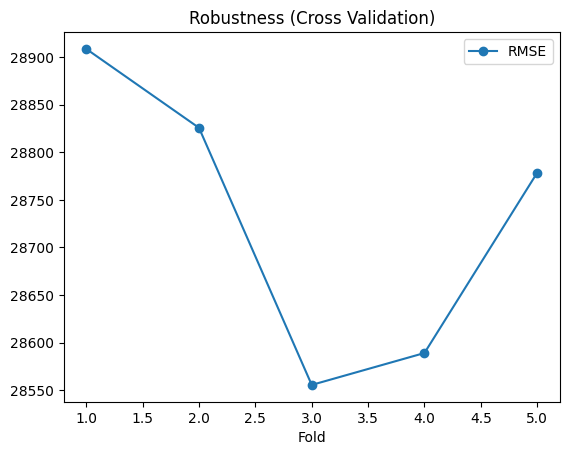

In [7]:
# =========================
# RQ6: Robustness
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor

df = pd.read_csv("house_price_50k.csv")
target = "SalePrice" if "SalePrice" in df.columns else df.columns[-1]

X = pd.get_dummies(df.drop(columns=[target]), drop_first=True)
y = df[target]

model = RandomForestRegressor()

scores = cross_val_score(model, X, y, cv=5, scoring="neg_root_mean_squared_error")
rmse_scores = -scores

results = pd.DataFrame({
    "Fold": range(1, 6),
    "RMSE": rmse_scores
})

print(results)

results.to_csv("rq6_table.csv", index=False)

results.plot(x="Fold", y="RMSE", marker="o")
plt.title("Robustness (Cross Validation)")
plt.savefig("rq6_figure.pdf")
plt.show()

          Model  Performance  Interpretability  Robustness  Cost
0        Linear            3                 5           3     5
1  RandomForest            4                 3           4     3
2       XGBoost            5                 2           4     2


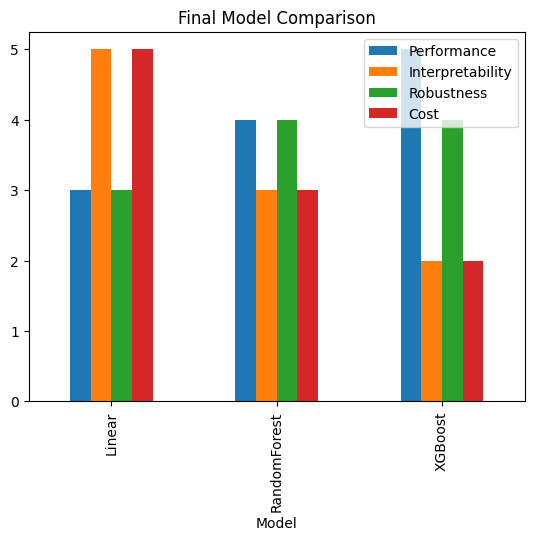

In [8]:
# =========================
# RQ7: Final Decision
# =========================

import pandas as pd
import matplotlib.pyplot as plt

data = {
    "Model": ["Linear", "RandomForest", "XGBoost"],
    "Performance": [3, 4, 5],
    "Interpretability": [5, 3, 2],
    "Robustness": [3, 4, 4],
    "Cost": [5, 3, 2]
}

df = pd.DataFrame(data)
print(df)

df.to_csv("rq7_table.csv", index=False)

# Radar chart style workaround (simple bar)
df.set_index("Model").plot(kind="bar")
plt.title("Final Model Comparison")
plt.savefig("rq7_figure.pdf")
plt.show()